## Reinforcement Learning

Reinforcement Learning (RL) is a paradigm of machine learning where an agent learns to make decisions by interacting with an environment. The goal of the agent is to maximize a cumulative reward signal over time.

### Core Components of Reinforcement Learning:

*   **Agent**: The learner or decision-maker that interacts with the environment.
*   **Environment**: The world or system with which the agent interacts. It defines the state space and the rules of interaction.
*   **State**: A snapshot of the environment at a particular moment in time, indicating where the agent is or the current situation.
*   **Action**: A choice or decision made by the agent that influences the environment, leading to a new state.
*   **Reward**: A scalar feedback signal from the environment to the agent, indicating how good or bad its last action was in a given state. The agent's goal is to maximize the total reward.

### Types of Reinforcement Learning:

1.  **Online vs. Offline Reinforcement Learning**:
    *   **Online RL**: The agent learns by directly interacting with the environment, often exploring different actions and observing their outcomes in real-time. This is common in simulations or real-world robotics where direct interaction is feasible.
    *   **Offline RL**: The agent learns from a fixed dataset of previously collected interactions, without further interaction with the environment. This is useful when interacting with the environment is costly, dangerous, or time-consuming.

2.  **Model-Based vs. Model-Free Reinforcement Learning**:
    *   **Model-Based RL**: The agent learns or is provided with a model of the environment. This model predicts the next state and reward given a current state and action. With a model, the agent can plan by simulating future outcomes.
    *   **Model-Free RL**: The agent learns directly from trial and error, without explicitly building or using a model of the environment. It learns policies or value functions directly from experience. The Q-learning and SARSA algorithms demonstrated in this notebook are examples of model-free RL.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random

The following class implements a simple grid-based maze environment and an agent that learns to navigate it using Q-learning, a model-free reinforcement learning algorithm. The agent receives rewards for reaching the goal and penalties for hitting walls or going out of bounds.

In [17]:
class MazeEnv:
    def __init__(self, maze, start, goal, actions,
                 reward_fire=-10, reward_goal=50, reward_step=-1):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.actions = actions
        self.height, self.width = maze.shape
        self.reward_fire = reward_fire
        self.reward_goal = reward_goal
        self.reward_step = reward_step
        self.state = start

    def reset(self):
        self.state = self.start
        return self.state

    def is_valid(self, pos):
        r, c = pos
        if r < 0 or r >= self.height:
            return False
        if c < 0 or c >= self.width:
            return False
        if self.maze[r, c] == 1:
            return False
        return True

    def step(self, action_index):
        move = self.actions[action_index]
        next_state = (self.state[0] + move[0], self.state[1] + move[1])

        if not self.is_valid(next_state):
            reward = self.reward_fire
            done = True
        elif next_state == self.goal:
            reward = self.reward_goal
            done = True
            self.state = next_state
        else:
            reward = self.reward_step
            done = False
            self.state = next_state

        return self.state, reward, done

Initialize a maze environment and an agent to navigate through it. The maze is represented as a grid, where the agent can move in four directions: up, down, left, and right. The agent receives rewards for reaching the goal and penalties for hitting walls or going out of bounds.

- Start at (0, 0) and aim to reach the goal at (9, 9).
- Possible actions: up, down, left, right.

In [18]:
maze = np.array([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
                 [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
                 [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
                 [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
                 [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
                 [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
                 [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
                 [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
                 [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]])

start = (0, 0)
goal = (9, 9)

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]  # left, right, up, down

num_episodes = 5000
alpha = 0.1      # learning rate
gamma = 0.9      # future importance
epsilon = 0.5    # exploration

reward_fire = -10
reward_goal = 50
reward_step = -1

In [19]:
# Helper Functions: Check if the move is valid
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True

Choose an action based on an epsilon-greedy policy, which balances exploration and exploitation. 

The agent will explore with a probability of epsilon and exploit the best-known action with a probability of 1 - epsilon. 

The Q-table is initialized to zeros, and it is updated based on the rewards received from the environment after taking actions.

In [20]:
def choose_action(state):
    Q = np.zeros((maze.shape[0], maze.shape[1], len(actions)))  # Q-table
    
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))  # explore
    else:
        return np.argmax(Q[state])  # exploit

Get optimal path from start to goal after training the agent. 

The optimal path is determined by following the actions with the highest Q-values in the Q-table, which represent the expected future rewards for taking those actions in each state. 

The agent will follow the path that leads to the highest cumulative reward, effectively navigating from the start position to the goal while avoiding walls and penalties.

In [21]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break

        visited.add(state)
        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path

In [22]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784',
                edgecolors='black', s=200, label='Start', zorder=5)

    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c',
                edgecolors='black', s=300, label='Goal', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Maze Navigation')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

Epsilon-greedy policy is a strategy used in reinforcement learning to balance exploration and exploitation. 

With a probability of epsilon, the agent will explore by choosing a random action, while with a probability of 1 - epsilon, it will exploit by choosing the action with the highest Q-value from the Q-table. 

This approach allows the agent to discover new strategies while still leveraging its existing knowledge to maximize rewards.

In [23]:
def epsilon_greedy_policy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 3)  # explore
    else:
        return np.argmax(Q[state[0], state[1]])  # exploit

SARSA (State-Action-Reward-State-Action) is an on-policy reinforcement learning algorithm that updates the Q-values based on the action taken in the next state. 

It differs from Q-learning, which is an off-policy algorithm that updates Q-values based on the maximum reward of the next state regardless of the action taken.

Formula:

$$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma Q(s', a') - Q(s, a)]$$

Where:
- $s$: current state
- $a$: action taken in state $s$
- $r$: reward received after taking action $a$ in state $s$
- $s'$: next state after taking action $a$
- $a'$: action taken in the next state $s'$

In [24]:
def sarsa(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.height, env.width, 4))  # 4 actions

    local_eps = epsilon
    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, local_eps)

        done = False

        while not done:
            next_state, reward, done = env.step(action)

            if not done:
                next_action = epsilon_greedy_policy(Q, next_state, local_eps)
                target = reward + gamma * Q[next_state[0], next_state[1], next_action]
            else:
                next_action = None
                target = reward

            Q[state[0], state[1], action] += alpha * (target - Q[state[0], state[1], action])

            state = next_state
            # if terminal, stop using next_action
            if next_action is None:
                break
            action = next_action

        local_eps = max(0.01, local_eps * 0.995)

    return Q

Q-learning is an off-policy reinforcement learning algorithm that learns the optimal action-value function, which gives the expected future rewards for taking a given action in a given state.

Formula:
$$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$$

Where:
- $s$: current state
- $a$: action taken in state $s$
- $r$: reward received after taking action $a$ in state $s$
- $s'$: next state after taking action $a$
- $\max_{a'} Q(s', a')$: maximum Q-value for the next state

In [25]:
def q_learning(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.height, env.width, 4))  # 4 actions

    local_eps = epsilon
    for episode in range(episodes):
        state = env.reset()

        done = False

        while not done:
            action = epsilon_greedy_policy(Q, state, local_eps)
            next_state, reward, done = env.step(action)

            best_next = np.max(Q[next_state[0], next_state[1]]) if not done else 0

            Q[state[0], state[1], action] += alpha * (reward + gamma * best_next
                                                      - Q[state[0], state[1], action])

            state = next_state

        local_eps = max(0.01, local_eps * 0.995)

    return Q

In [26]:
def episodic_q_learning(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.height, env.width, len(env.actions)))

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = epsilon_greedy_policy(Q, state, epsilon)
            next_state, reward, done = env.step(action)
            next_max = np.max(Q[next_state[0], next_state[1]]) if not done else 0

            Q[state[0], state[1], action] += alpha * (reward + gamma * next_max
                                                       - Q[state[0], state[1], action])

            state = next_state

        epsilon = max(0.01, epsilon * 0.995)

    return Q

In [27]:
def plot_maze_with_paths(paths, labels, colors=None):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='lightgreen',
                edgecolors='black', s=200, label='Start', zorder=5)

    plt.scatter(goal[1], goal[0], marker='*', color='green',
                edgecolors='black', s=300, label='Goal', zorder=5)

    if colors is None:
        colors = ['red', 'blue', 'green']

    for path, label, color in zip(paths, labels, colors):
        if not path:
            continue
        rows, cols = zip(*path)
        plt.plot(cols, rows, color=color, linewidth=4,
                 label=label, zorder=4)

    plt.title('Reinforcement Learning: Maze Navigation (3 algorithms)')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

In [28]:
def plot_three_maze_subplots(paths, labels, colors=None):
    if colors is None:
        colors = ['red', 'blue', 'green']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, path, label, color in zip(axes, paths, labels, colors):
        cmap = ListedColormap(['#eef8ea', '#a8c79c'])
        ax.imshow(maze, cmap=cmap)

        ax.scatter(start[1], start[0], marker='o', color='lightgreen',
               edgecolors='black', s=150, zorder=5)
        ax.scatter(goal[1], goal[0], marker='*', color='green',
               edgecolors='black', s=200, zorder=5)

        if path:
            rows, cols = zip(*path)
            ax.plot(cols, rows, color=color, linewidth=4, zorder=4)

        ax.set_title(label)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [29]:
def plot_qtable_subplots(Qs, labels, cmap='viridis'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    h, w = maze.shape
    for ax, Q, label in zip(axes, Qs, labels):
        Qmax = np.max(Q, axis=2)
        im = ax.imshow(Qmax, cmap=cmap)
        ax.set_title(label + ' (max action value)')
        ax.invert_yaxis()
        ax.grid(False)

        # annotate values and mark walls
        for i in range(h):
            for j in range(w):
                if maze[i, j] == 1:
                    ax.text(j, i, 'X', ha='center', va='center', color='white', fontsize=8)
                else:
                    ax.text(j, i, f"{Qmax[i, j]:.1f}", ha='center', va='center', color='white', fontsize=7)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

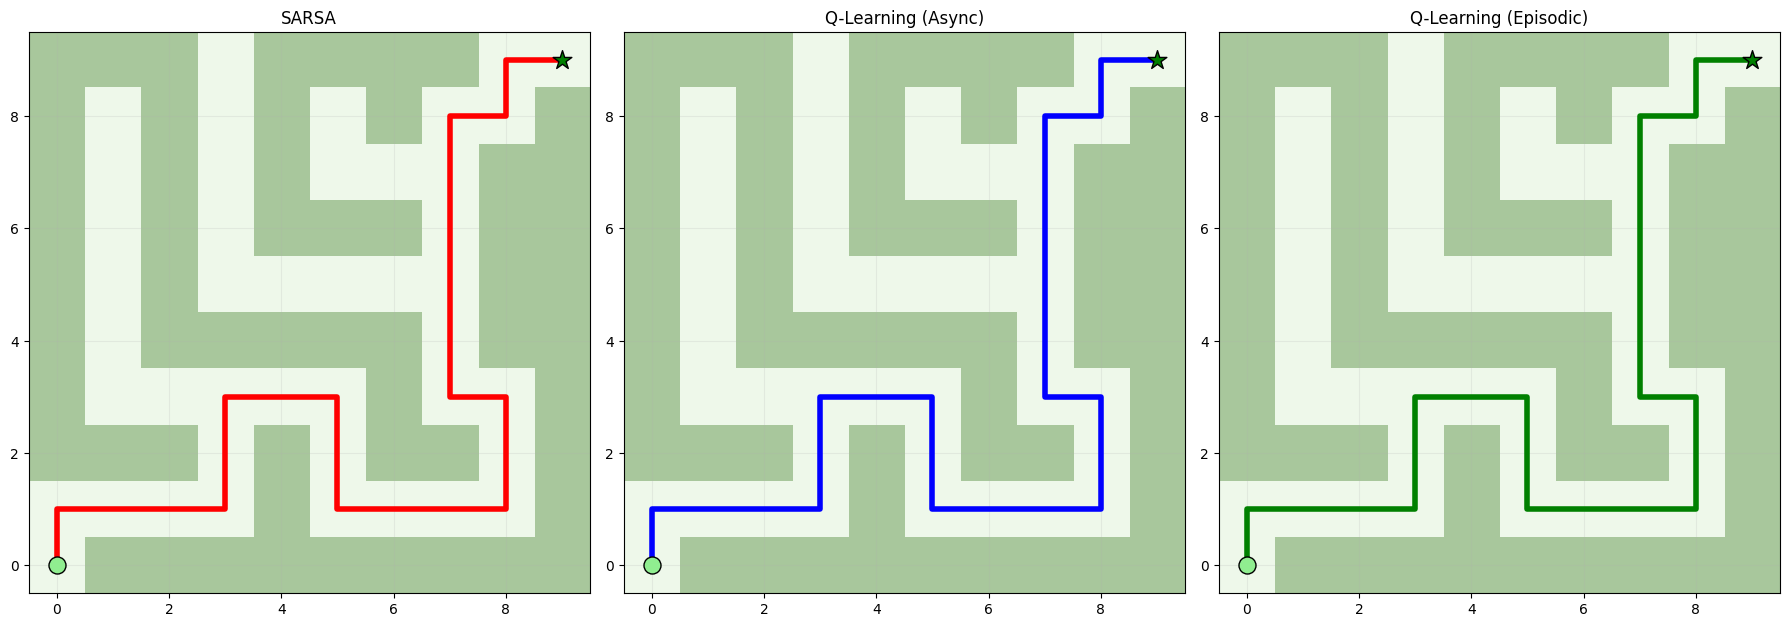

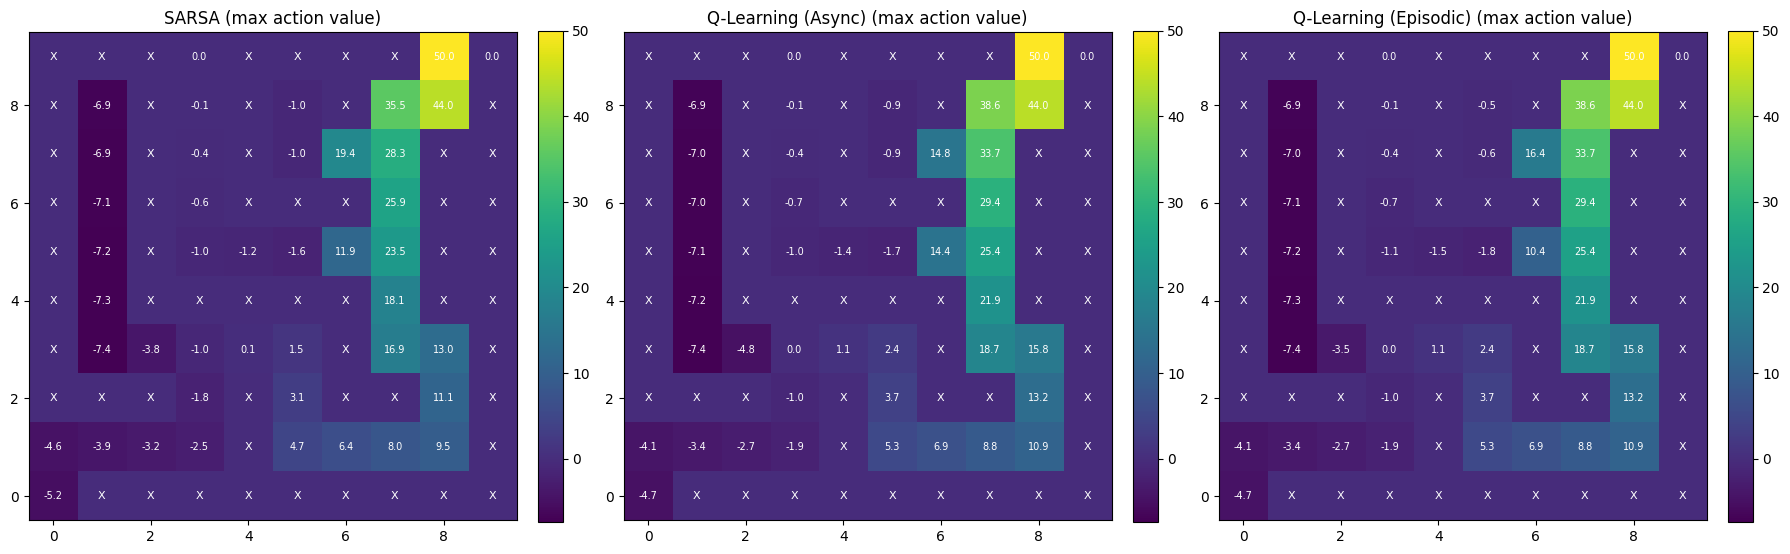

In [30]:
env = MazeEnv(maze, start, goal, actions,
              reward_fire=reward_fire, reward_goal=reward_goal, reward_step=reward_step)

# Run SARSA
Q_sarsa = sarsa(env, num_episodes, alpha, gamma, epsilon)

# Run Q-Learning (function defined above)
Q_qlearn = q_learning(env, num_episodes, alpha, gamma, epsilon)

# Run episodic tabular Q-learning (same style as original loop)
Q_episodic = episodic_q_learning(env, num_episodes, alpha, gamma, epsilon)

# Extract optimal paths
path_sarsa = get_optimal_path(Q_sarsa, start, goal, actions, maze)
path_qlearn = get_optimal_path(Q_qlearn, start, goal, actions, maze)
path_episodic = get_optimal_path(Q_episodic, start, goal, actions, maze)

labels = ['SARSA', 'Q-Learning (Async)', 'Q-Learning (Episodic)']

# Plot three maze subplots (one per algorithm)
plot_three_maze_subplots([path_sarsa, path_qlearn, path_episodic], labels)

# Plot Q-table heatmaps (max over actions) for each algorithm
plot_qtable_subplots([Q_sarsa, Q_qlearn, Q_episodic], labels)